# Cardiovascular disease classifier

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

from xgboost import XGBClassifier

RANDOM_STATE = 55

### Attribute Information
<pre>
- Age:            age of the patient [years]
- Sex:            sex of the patient [M: Male, F: Female]
- ChestPainType:  chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP:      resting blood pressure [mm Hg]
- Cholesterol:    serum cholesterol [mm/dl]
- FastingBS:      fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG:     resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR:          maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak:        oldpeak = ST [Numeric value measured in depression]
- ST_Slope:       the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease:   output class [1: heart disease, 0: Normal]

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### One hot encoding

In [3]:
one_hot = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

df = pd.get_dummies(
    data = df,
    prefix=one_hot,
    columns=one_hot
)

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [4]:
X = df.drop('HeartDisease',axis=1)
Y = df['HeartDisease']

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   Sex_F              918 non-null    bool   
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ASY  918 non-null    bool   
 9   ChestPainType_ATA  918 non-null    bool   
 10  ChestPainType_NAP  918 non-null    bool   
 11  ChestPainType_TA   918 non-null    bool   
 12  RestingECG_LVH     918 non-null    bool   
 13  RestingECG_Normal  918 non-null    bool   
 14  RestingECG_ST      918 non-null    bool   
 15  ExerciseAngina_N   918 non-null    bool   
 16  ExerciseAngina_Y   918 non

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,train_size=0.8,random_state=RANDOM_STATE)

print(f"Train samples : {len(X_train)}\nTest sample : {len(X_test)}")
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

Train samples : 734
Test sample : 184
target proportion: 0.5518


## Building three models and testing their baseline performance

### 1) Decision Tree Model

Decision Tree Classifier
Decision Tree Performance:
Accuracy: 0.81
Precision: 0.85
Recall: 0.80
F1: 0.82


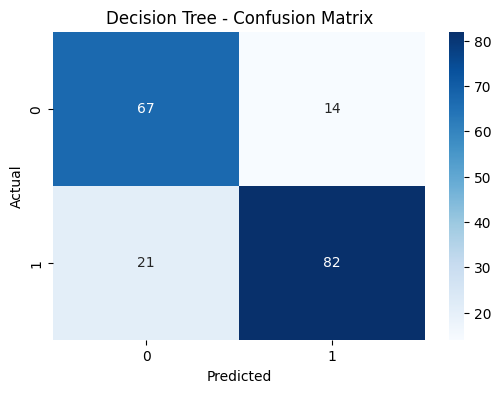


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79        81
           1       0.85      0.80      0.82       103

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



In [ ]:
print("="*50)
print("Decision Tree Classifier")
print("="*50)

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.2f}")
print(f"Precision: {precision_score(y_test,y_pred_dt):.2f}")
print(f"Recall: {recall_score(y_test,y_pred_dt):.2f}")
print(f"F1: {f1_score(y_test,y_pred_dt):.2f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


### 2) Random Forest Model

Random Forest Classifier
Random Forest Performance:
Accuracy: 0.89
Precision: 0.90
Recall: 0.90
F1: 0.90


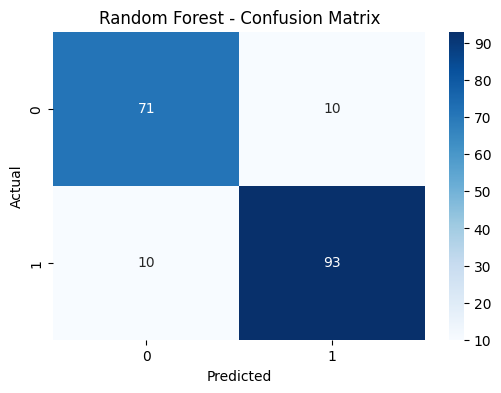


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        81
           1       0.90      0.90      0.90       103

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
print("="*50)
print("Random Forest Classifier")
print("="*50)

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test,y_pred_rf):.2f}")
print(f"Recall: {recall_score(y_test,y_pred_rf):.2f}")
print(f"F1: {f1_score(y_test,y_pred_rf):.2f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

### 3) XGBoost

XGBoost Classifier
XGBoost Performance:
Accuracy: 0.87
Precision: 0.91
Recall: 0.85
F1: 0.88


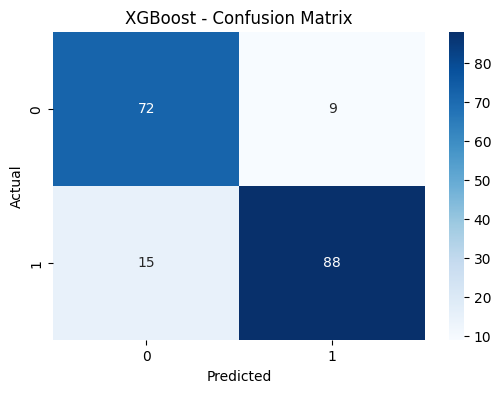


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        81
           1       0.91      0.85      0.88       103

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [24]:
print("="*50)
print("XGBoost Classifier")
print("="*50)

xg_model = XGBClassifier(random_state=RANDOM_STATE)
xg_model.fit(X_train,y_train)

y_pred_xg = xg_model.predict(X_test)

print("XGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_xg):.2f}")
print(f"Precision: {precision_score(y_test,y_pred_xg):.2f}")
print(f"Recall: {recall_score(y_test,y_pred_xg):.2f}")
print(f"F1: {f1_score(y_test,y_pred_xg):.2f}")

# Plotting confusion matrix
plt.figure(figsize=(6, 4))
cm_dt = confusion_matrix(y_test, y_pred_xg)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))

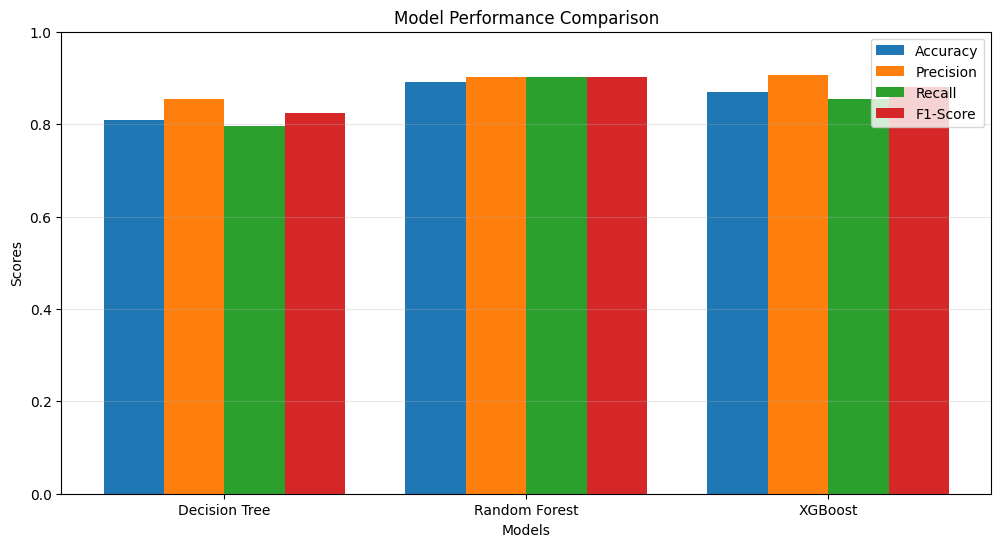

In [25]:
# COMPARISON PLOT - All Models
models = ['Decision Tree', 'Random Forest', 'XGBoost']
accuracy = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xg)
]
precision = [
    precision_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xg)
]
recall = [
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xg)
]
f1 = [
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xg)
]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1-Score')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.legend()
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Key Insights:
<pre>
Random Forest is the winner - Best overall performance across all metrics
Random Forest has the best recall (90%) - Only misses 10 heart disease cases vs 21 (Decision Tree) and 15 (XGBoost)
XGBoost has highest precision (91%) - Most accurate when it predicts heart disease
Decision Tree is the weakest - Expected since it's a single tree vs ensemble methods